sigmoid : bounded between 0-1/ monotonic/smooth - its derivative exista at every point /nonlinear
reLU - max with 0, simple and effectiv
tanh - sigmoid but -1 ->1 bounded
softmax - in output layer normalize output - prob distr over classes
leaky reLU - max with 0.1*x->: non zero grad 
elu - negativ saturation for negativ values


In [2]:
import torch

torch.cuda.is_available()

False

In [2]:
x = torch.tensor([2.0], requires_grad=True)
# require_grad -> track gradients 
print(x)

tensor([2.], requires_grad=True)


In [3]:
y = x ** 2 + 2 * x + 1
print(y)

tensor([9.], grad_fn=<AddBackward0>)


In [4]:
y.backward() #gradient of y with respect to x

In [5]:
x.grad

tensor([6.])

In [6]:
import torch

# Create a tensor with requires_grad=True
x = torch.tensor([1., 2., 3.], requires_grad=True)

# Compute a function of x
y = x.sum()

# Compute gradients of y with respect to x
y.backward()

# Print gradients of x
print(x.grad)

tensor([1., 1., 1.])


In [13]:

#Exercise 1.

#Compute the gradient for the sigmoid activation function in 2 points using pytorch and check it with the known explicit formula

import torch
x=torch.tensor([1.0,2.0],requires_grad=True)
y=1/(1+ torch.exp(-x))
y.sum().backward()
print(x.grad)

tensor([0.1966, 0.1050])


sigmoid derivative is s'(x)=s(x)*(1-s(x))


In [12]:
with torch.no_grad():
    sigmoid=1/(1+torch.exp(-x))
    explicit_grad=sigmoid*(1-sigmoid)
print("Explicit formula : ",explicit_grad)

Explicit formula :  tensor([0.1966, 0.1050])


In [14]:
#Exercise 2.

#Compute the gradient for the linear activation function in 2 points using pytorch and check it with the known explicit formula
import torch
x2=torch.tensor([1.,2.],requires_grad=True)
y2=x2
y2.sum().backward()
print(x2.grad)


tensor([1., 1.])


In [15]:
#Execise 3.

#Compute the gradient for the relu activation function in 2 points using pytorch and check it with the known explicit formula.
import torch
x3=torch.tensor([-1.,1.],requires_grad=True)
y3=torch.relu(x3)
y3.sum().backward()
print(x3.grad)

tensor([0., 1.])


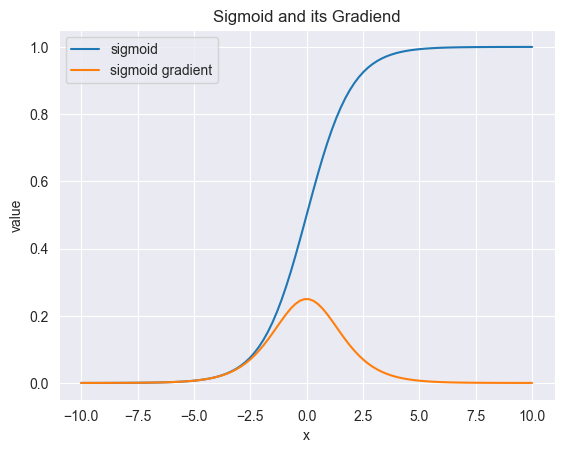

In [17]:
#Exercise 4.

#Write in python a function to plot the sigmoid activation function and its gradient using matplotlib

from matplotlib import pyplot as plt
x=torch.linspace(-10,10,100,requires_grad=True)
y=1/(1+torch.exp(-x))
y.sum().backward()
grad=x.grad

x_np=x.detach().numpy()
y_np=y.detach().numpy()
grad_np=grad.detach().numpy()

plt.plot(x_np,y_np,label="sigmoid")
plt.plot(x_np,grad_np,label="sigmoid gradient")
plt.legend()
plt.title("Sigmoid and its Gradiend")
plt.xlabel("x")
plt.ylabel("value")
plt.show()



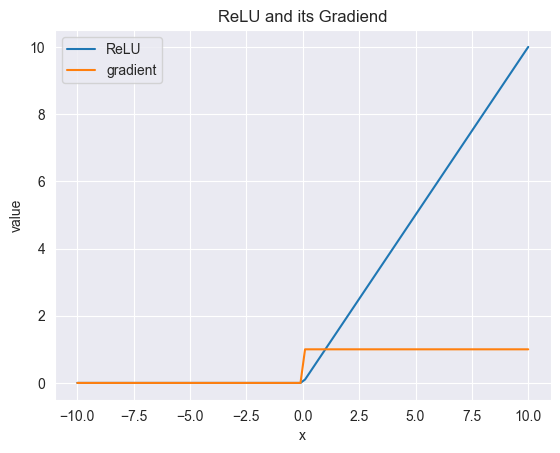

In [18]:
#Exercise 5.

#Write in python a function to plot the ReLU activation function and its gradient using matplotlib.
from matplotlib import pyplot as plt

x=torch.linspace(-10,10,100,requires_grad=True)
y=torch.relu(x)
y.sum().backward()
grad=x.grad

x_np=x.detach().numpy()
y_np=y.detach().numpy()
grad_np=grad.detach().numpy()

plt.plot(x_np,y_np,label="ReLU")
plt.plot(x_np,grad_np,label="gradient")
plt.legend()
plt.title("ReLU and its Gradient")
plt.xlabel("x")
plt.ylabel("value")
plt.show()

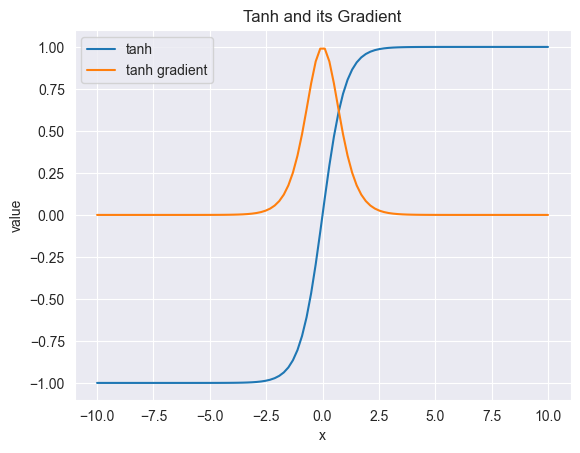

In [20]:
#Exercise 6.

#Write in python a function to plot the tanh activation function and its gradient using matplotlib.

from matplotlib import pyplot as plt
import torch
x=torch.linspace(-10,10,100,requires_grad=True)
y=torch.tanh(x)
y.sum().backward()
grad=x.grad

x_np=x.detach().numpy()
y_np=y.detach().numpy()
grad_np=grad.detach().numpy()

plt.plot(x_np,y_np,label="tanh")
plt.plot(x_np,grad_np,label="tanh gradient")
plt.legend()
plt.title("Tanh and its Gradient")
plt.xlabel("x")
plt.ylabel("value")
plt.show()

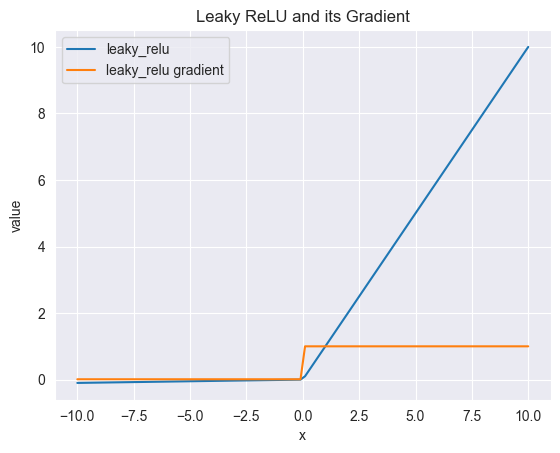

In [22]:
#Exercise 7.

#Write in python a function to plot the leaky ReLU activation function and its gradient using matplotlib.

from matplotlib import pyplot as plt
import torch
import torch.nn.functional as F
x=torch.linspace(-10,10,100,requires_grad=True)
y=torch.max(0.01*x,x)
#y=F.leaky_relu(x,negative_slope=0.01)
y.sum().backward()
grad=x.grad

x_np=x.detach().numpy()
y_np=y.detach().numpy()
grad_np=grad.detach().numpy()

plt.plot(x_np,y_np,label="leaky_relu")
plt.plot(x_np,grad_np,label="leaky_relu gradient")
plt.legend()
plt.title("Leaky ReLU and its Gradient")
plt.xlabel("x")
plt.ylabel("value")
plt.show()


In [23]:
import torch
import torch.nn as nn

input_size = 2
output_size = 1

class Perceptron(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Perceptron, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
        self.activation = torch.nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear(x)
        x = self.activation(x)
        return x


In [24]:
perceptron = Perceptron(input_size, output_size)
x = torch.tensor([0.5, 0.2])
y = perceptron(x)
print(y)

tensor([0.4394], grad_fn=<SigmoidBackward0>)


In [25]:

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = torch.optim.SGD(perceptron.parameters(), lr=0.1)  # Stochastic gradient descent optimizer

# Generate some random input data and labels
input_data = torch.randn((10, input_size))
labels = torch.randint(0, 2, (10, output_size)).float()

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = perceptron(input_data)
    loss = criterion(outputs, labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print the loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.6045
Epoch [200/1000], Loss: 0.5967
Epoch [300/1000], Loss: 0.5943
Epoch [400/1000], Loss: 0.5935
Epoch [500/1000], Loss: 0.5932
Epoch [600/1000], Loss: 0.5932
Epoch [700/1000], Loss: 0.5931
Epoch [800/1000], Loss: 0.5931
Epoch [900/1000], Loss: 0.5931
Epoch [1000/1000], Loss: 0.5931


In [ ]:
# Exercise 8:
# 
# Implement a binary classification model using the Perceptron class in PyTorch for the logic OR.
# 
# Your task is to create a Perceptron instance and train it using a proper dataset and the binary cross-entropy loss with stochastic gradient descent optimizer.
# 
# Here are the steps you can follow:
# 
# Define a Perceptron class that inherits from torch.nn.Module and implements a binary classification model.
# 
# Define a binary cross-entropy loss function using the torch.nn.BCEWithLogitsLoss module.
# 
# Define a stochastic gradient descent optimizer using the torch.optim.SGD module.
# 
# Train the Perceptron model on the training set using the binary cross-entropy loss and stochastic gradient descent optimizer.
# 
# Evaluate the trained model compute the accuracy.

In [8]:
import torch
import torch.nn as nn

input_size = 2
output_size = 1

class MyPerceptron(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MyPerceptron, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        return self.linear(x)
        

my_perceptron = MyPerceptron(input_size, output_size)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(my_perceptron.parameters(),lr=0.1)

input_data=torch.tensor(
    [
        [0.,0.],
        [0.,1.],
        [1.,0.],
        [1.,1.]
    ]
)
labels=torch.tensor(
    [
        [0.],
        [1.],
        [1.],
        [1.]
    ]
)

num_epochs = 50
for epoch in range(num_epochs):
    outputs=my_perceptron(input_data)
    loss=criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
    

with torch.no_grad():
    outputs=my_perceptron(input_data)
    probs=torch.sigmoid(outputs)
    predictions=probs>0.5
    accuracy=(predictions.float()==labels).float().mean()

print("Accuracy:", accuracy.item())





Accuracy: 0.75
